# Laboratorio 5.2 — Malware Prediction con PyTorch
**Autor:** Valencia Medina Freddy D.  
**Dataset:** Microsoft Malware Prediction (`HasDetections`)  
**Objetivo:** Adaptar el laboratorio de clasificación a PyTorch aplicando lo visto en cuadernillos 01, 02, 03 y 04 (`tensores`, `nn.Module`, `Dataset/DataLoader`, `checkpoints`).

## Alcance
1. Reutilizar preprocesamiento del laboratorio anterior.
2. Entrenar una red neuronal para clasificación binaria con PyTorch.
3. Guardar datos preprocesados para reanudar entrenamiento en sesión GPU.
4. Guardar y cargar checkpoints del mejor modelo para evaluación e inferencia.

## Carga y exploración inicial
Se carga un subconjunto del dataset y se revisan dimensiones, distribución del target y porcentaje de nulos para definir la limpieza previa al entrenamiento.

In [4]:
import os
import time
import json
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
 )

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/microsoft-malware-prediction/sample_submission.csv
/kaggle/input/competitions/microsoft-malware-prediction/train.csv
/kaggle/input/competitions/microsoft-malware-prediction/test.csv


In [5]:
ruta = '/kaggle/input/competitions/microsoft-malware-prediction/train.csv'
t0_carga_dataset = time.time()

# Puedes subir o bajar nrows segun RAM disponible
df = pd.read_csv(ruta, nrows=2_000_000, low_memory=False)

elapsed_carga_dataset = time.time() - t0_carga_dataset
print('Shape:', df.shape)
print(f'Tiempo de carga dataset: {elapsed_carga_dataset:.2f} s')
print('Distribucion del target:')
print(df['HasDetections'].value_counts())
print('Tasa de malware: {:.2f}%'.format(df['HasDetections'].mean() * 100))

pd.set_option('display.max_rows', None)
print(df.isnull().sum() / len(df) * 100)

Shape: (2000000, 83)
Tiempo de carga dataset: 32.04 s
Distribucion del target:
HasDetections
0    1000073
1     999927
Name: count, dtype: int64
Tasa de malware: 50.00%
MachineIdentifier                                     0.00000
ProductName                                           0.00000
EngineVersion                                         0.00000
AppVersion                                            0.00000
AvSigVersion                                          0.00000
IsBeta                                                0.00000
RtpStateBitfield                                      0.36210
IsSxsPassiveMode                                      0.00000
DefaultBrowsersIdentifier                            95.14060
AVProductStatesIdentifier                             0.40795
AVProductsInstalled                                   0.40795
AVProductsEnabled                                     0.40795
HasTpm                                                0.00000
CountryIdentifier        

## Preparación de datos
Se separa el target (`HasDetections`), se eliminan columnas con demasiados nulos, se codifican categoricas y se imputan nulos numericos para obtener una matriz totalmente numerica lista para PyTorch.
Ademas, se aplica ingenieria de caracteristicas con tres ideas:
1. descomposicion de versiones (`major/minor`),
2. variables cruzadas de riesgo y razones numericas,
3. codificacion hibrida de categoricas: one-hot para baja cardinalidad y frequency encoding para alta cardinalidad.

In [6]:
# Separamos el target antes de cualquier transformación
y_full = df['HasDetections'].values

# Eliminamos columnas que no aportan información al modelo
df = df.drop(columns=['MachineIdentifier', 'HasDetections'])

print('Target separado:', y_full.shape)
print('Columnas restantes:', df.shape[1])

Target separado: (2000000,)
Columnas restantes: 81


In [7]:
# Porcentaje de nulos por columna
nulos_pct = df.isnull().sum() / len(df) * 100

# Columnas a eliminar (50% o más de nulos)
cols_eliminar = nulos_pct[nulos_pct >= 50].index

# Mostrar cuáles se eliminan
print('Columnas que se eliminarán:')
for col in cols_eliminar:
    print(f'  {col:<50} {nulos_pct[col]:.1f}% nulos')

# Eliminar
df = df.drop(columns=cols_eliminar)

print()
print('Columnas antes:', len(nulos_pct))
print('Columnas después:', df.shape[1])
print('Columnas eliminadas:', len(cols_eliminar))

Columnas que se eliminarán:
  DefaultBrowsersIdentifier                          95.1% nulos
  PuaMode                                            100.0% nulos
  Census_ProcessorClass                              99.6% nulos
  Census_InternalBatteryType                         71.0% nulos
  Census_IsFlightingInternal                         83.0% nulos
  Census_ThresholdOptIn                              63.5% nulos
  Census_IsWIMBootEnabled                            63.4% nulos

Columnas antes: 81
Columnas después: 74
Columnas eliminadas: 7


In [8]:
# Identificar columnas de texto (categóricas)
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Columnas categóricas: {len(cat_cols)}')
print()
for col in cat_cols:
    print(f'  {col:<50} {df[col].nunique()} valores únicos')

Columnas categóricas: 26

  ProductName                                        6 valores únicos
  EngineVersion                                      64 valores únicos
  AppVersion                                         99 valores únicos
  AvSigVersion                                       7974 valores únicos
  Platform                                           4 valores únicos
  Processor                                          3 valores únicos
  OsVer                                              33 valores únicos
  OsPlatformSubRelease                               9 valores únicos
  OsBuildLab                                         544 valores únicos
  SkuEdition                                         8 valores únicos
  SmartScreen                                        15 valores únicos
  Census_MDC2FormFactor                              12 valores únicos
  Census_DeviceFamily                                3 valores únicos
  Census_PrimaryDiskTypeName                         4

In [9]:
# Feature engineering antes de eliminar columnas de alta cardinalidad
version_cols = ['AvSigVersion', 'EngineVersion', 'AppVersion', 'Census_OSVersion']
version_cols_presentes = [c for c in version_cols if c in df.columns]
nuevas_version = 0
nuevas_interacciones = []
eps = 1e-6

# 1) Versiones separadas en major/minor (mas informativo que tratar la version completa como texto)
for col in version_cols_presentes:
    parts = (
        df[col]
        .fillna('0.0')
        .astype(str)
        .str.extract(r'(?P<major>\d+)\.(?P<minor>\d+)')
    )
    df[f'{col}_major'] = pd.to_numeric(parts['major'], errors='coerce').fillna(0).astype(np.float32)
    df[f'{col}_minor'] = pd.to_numeric(parts['minor'], errors='coerce').fillna(0).astype(np.float32)
    nuevas_version += 2

# 2) Senal de calidad por fila: cantidad y proporcion de nulos
n_cols_base = float(df.shape[1])
row_nulls = df.isnull().sum(axis=1).astype(np.float32)
df['num_nulos_fila'] = row_nulls
df['ratio_nulos_fila'] = (row_nulls / max(n_cols_base, 1.0)).astype(np.float32)
nuevas_interacciones.extend(['num_nulos_fila', 'ratio_nulos_fila'])

# 3) Interacciones numericas utiles
if {'Census_TotalPhysicalRAM', 'Census_ProcessorCoreCount'}.issubset(df.columns):
    ram = pd.to_numeric(df['Census_TotalPhysicalRAM'], errors='coerce').fillna(0)
    cores = pd.to_numeric(df['Census_ProcessorCoreCount'], errors='coerce').fillna(1)
    df['ram_por_nucleo'] = (ram / np.clip(cores, 1, None)).astype(np.float32)
    nuevas_interacciones.append('ram_por_nucleo')

if {'Census_SystemVolumeTotalCapacity', 'Census_PrimaryDiskTotalCapacity'}.issubset(df.columns):
    sys_vol = pd.to_numeric(df['Census_SystemVolumeTotalCapacity'], errors='coerce').fillna(0)
    disk_tot = pd.to_numeric(df['Census_PrimaryDiskTotalCapacity'], errors='coerce').fillna(0)
    df['ratio_sistema_disco'] = (sys_vol / (disk_tot + eps)).astype(np.float32)
    nuevas_interacciones.append('ratio_sistema_disco')

if {'Census_InternalPrimaryDisplayResolutionHorizontal', 'Census_InternalPrimaryDisplayResolutionVertical'}.issubset(df.columns):
    hres = pd.to_numeric(df['Census_InternalPrimaryDisplayResolutionHorizontal'], errors='coerce').fillna(0)
    vres = pd.to_numeric(df['Census_InternalPrimaryDisplayResolutionVertical'], errors='coerce').fillna(0)
    df['pixeles_pantalla'] = (hres * vres).astype(np.float32)
    df['aspect_ratio_pantalla'] = (hres / (vres + eps)).astype(np.float32)
    nuevas_interacciones.extend(['pixeles_pantalla', 'aspect_ratio_pantalla'])

if {'AVProductsEnabled', 'AVProductsInstalled'}.issubset(df.columns):
    av_on = pd.to_numeric(df['AVProductsEnabled'], errors='coerce').fillna(0)
    av_inst = pd.to_numeric(df['AVProductsInstalled'], errors='coerce').fillna(0)
    df['ratio_av_activo'] = (av_on / (av_inst + eps)).astype(np.float32)
    nuevas_interacciones.append('ratio_av_activo')

# 4) Interaccion de riesgo: firma antigua + firewall apagado
if {'AvSigVersion_major', 'Firewall'}.issubset(df.columns):
    sig_major = pd.to_numeric(df['AvSigVersion_major'], errors='coerce').fillna(0)
    fw = pd.to_numeric(df['Firewall'], errors='coerce').fillna(1)
    q30_sig = float(sig_major.quantile(0.30))
    df['firma_antigua'] = (sig_major <= q30_sig).astype(np.float32)
    df['firewall_off'] = (fw == 0).astype(np.float32)
    df['riesgo_fw_firma'] = ((df['firma_antigua'] == 1) & (df['firewall_off'] == 1)).astype(np.float32)
    nuevas_interacciones.extend(['firma_antigua', 'firewall_off', 'riesgo_fw_firma'])

# 5) Interaccion categorica cruzada (se codificara luego)
if {'Census_DeviceFamily', 'Census_MDC2FormFactor'}.issubset(df.columns):
    df['device_form_factor'] = (
        df['Census_DeviceFamily'].fillna('missing').astype(str) + '__' +
        df['Census_MDC2FormFactor'].fillna('missing').astype(str)
    )
    nuevas_interacciones.append('device_form_factor')

# Eliminamos columnas originales de alta cardinalidad
cols_alta_cardinalidad = ['AvSigVersion', 'OsBuildLab', 'Census_OSVersion', 'AppVersion', 'EngineVersion']
cols_alta_cardinalidad = [c for c in cols_alta_cardinalidad if c in df.columns]
df = df.drop(columns=cols_alta_cardinalidad)

print('Features de version creadas:', nuevas_version)
print('Nuevas features/interacciones:', len(nuevas_interacciones))
print('Columnas eliminadas por alta cardinalidad:', len(cols_alta_cardinalidad))
print('Columnas despues de ingenieria + limpieza:', df.shape[1])
print('Ejemplos de nuevas columnas:', nuevas_interacciones[:8])

Features de version creadas: 8
Nuevas features/interacciones: 11
Columnas eliminadas por alta cardinalidad: 5
Columnas despues de ingenieria + limpieza: 88
Ejemplos de nuevas columnas: ['num_nulos_fila', 'ratio_nulos_fila', 'ram_por_nucleo', 'ratio_sistema_disco', 'pixeles_pantalla', 'aspect_ratio_pantalla', 'ratio_av_activo', 'firma_antigua']


In [10]:
# Identificar columnas categoricas restantes
cat_cols = df.select_dtypes(include='object').columns.tolist()

LOW_CARD_THRESHOLD = 15
cardinalidad = {col: df[col].nunique(dropna=False) for col in cat_cols}
onehot_cols = [c for c in cat_cols if cardinalidad[c] <= LOW_CARD_THRESHOLD]
freq_cols = [c for c in cat_cols if cardinalidad[c] > LOW_CARD_THRESHOLD]

# A) One-Hot para baja cardinalidad (mas semantico para redes neuronales)
if len(onehot_cols) > 0:
    for col in onehot_cols:
        df[col] = df[col].fillna('missing').astype(str)
    df = pd.get_dummies(
        df,
        columns=onehot_cols,
        prefix=onehot_cols,
        dummy_na=False,
        dtype=np.float32,
    )

# B) Frequency Encoding para alta cardinalidad
for col in freq_cols:
    s = df[col].fillna('missing').astype(str)
    freqs = s.value_counts(normalize=True)
    df[col] = s.map(freqs).fillna(0.0).astype(np.float32)

print(f'Columnas categoricas detectadas: {len(cat_cols)}')
print(f'One-hot (<= {LOW_CARD_THRESHOLD} unicos): {len(onehot_cols)}')
print(f'Frequency encoding (> {LOW_CARD_THRESHOLD} unicos): {len(freq_cols)}')
if len(onehot_cols) > 0:
    print('Ejemplo one-hot:', onehot_cols[:8])
if len(freq_cols) > 0:
    print('Ejemplo frequency:', freq_cols[:8])

# Validacion final: que no queden columnas object
objetos_restantes = df.select_dtypes(include='object').columns.tolist()
print('Columnas object restantes:', len(objetos_restantes))

Columnas categoricas detectadas: 22
One-hot (<= 15 unicos): 15
Frequency encoding (> 15 unicos): 7
Ejemplo one-hot: ['ProductName', 'Platform', 'Processor', 'OsPlatformSubRelease', 'SkuEdition', 'Census_MDC2FormFactor', 'Census_DeviceFamily', 'Census_PrimaryDiskTypeName']
Ejemplo frequency: ['OsVer', 'SmartScreen', 'Census_ChassisTypeName', 'Census_OSBranch', 'Census_OSEdition', 'Census_OSSkuName', 'device_form_factor']
Columnas object restantes: 0


In [11]:
# Rellenar nulos numéricos con la mediana de cada columna
cols_numericas = df.select_dtypes(include='number').columns.tolist()

for col in cols_numericas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# Verificar que no queden nulos
print('Nulos restantes:', df.isnull().sum().sum())
print('Columnas numéricas imputadas:', len(cols_numericas))

Nulos restantes: 0
Columnas numéricas imputadas: 170


## Implementación PyTorch
### Split estratificado Train/Test
Se usa división 80/20 estratificada para mantener la proporción de clases entre entrenamiento y test.

In [12]:
X_full = df.values.astype(np.float32)
y_full = y_full.astype(np.float32)

# Split en dos pasos para conservar test limpio
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full,
    shuffle=True,
 )

# De X_temp (80%), sacamos validacion del 12.5% => 10% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp,
    shuffle=True,
 )

print(f'X_train: {X_train.shape} | Malware train: {int(y_train.sum()):,}')
print(f'X_val:   {X_val.shape} | Malware val:   {int(y_val.sum()):,}')
print(f'X_test:  {X_test.shape} | Malware test:  {int(y_test.sum()):,}')
print(f'Proporcion malware train: {y_train.mean()*100:.2f}%')
print(f'Proporcion malware val:   {y_val.mean()*100:.2f}%')
print(f'Proporcion malware test:  {y_test.mean()*100:.2f}%')

X_train: (1400000, 170) | Malware train: 699,949
X_val:   (200000, 170) | Malware val:   99,993
X_test:  (400000, 170) | Malware test:  199,985
Proporcion malware train: 50.00%
Proporcion malware val:   50.00%
Proporcion malware test:  50.00%


### Normalización y checkpoint de datos
Se normalizan features con estadísticos de train y se guardan arrays (`X_train_norm`, `X_test_norm`, `y_train`, `y_test`, `mu`, `sigma`) para reanudar entrenamiento en otra sesión sin repetir preprocesamiento.

In [13]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1       # evitar division por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

print('Funcion featureNormalize creada correctamente')

Funcion featureNormalize creada correctamente


In [14]:
X_train_norm, mu, sigma = featureNormalize(X_train)
X_val_norm = (X_val - mu) / sigma
X_test_norm = (X_test - mu) / sigma

print(f'Media de X_train_norm: {X_train_norm.mean():.4f}')
print(f'Std de X_train_norm:   {X_train_norm.std():.4f}')
print(f'Media de X_val_norm:   {X_val_norm.mean():.4f}')
print(f'Media de X_test_norm:  {X_test_norm.mean():.4f}')

print('Verificacion de normalizacion (sin NaN/Inf):')
print('Train finito:', np.isfinite(X_train_norm).all())
print('Val finito:  ', np.isfinite(X_val_norm).all())
print('Test finito: ', np.isfinite(X_test_norm).all())

# Checkpoint de datos para sesion GPU
np.save('/kaggle/working/X_train_norm.npy', X_train_norm.astype(np.float32))
np.save('/kaggle/working/X_val_norm.npy', X_val_norm.astype(np.float32))
np.save('/kaggle/working/X_test_norm.npy', X_test_norm.astype(np.float32))
np.save('/kaggle/working/y_train.npy', y_train.astype(np.float32))
np.save('/kaggle/working/y_val.npy', y_val.astype(np.float32))
np.save('/kaggle/working/y_test.npy', y_test.astype(np.float32))
np.save('/kaggle/working/mu.npy', mu.astype(np.float32))
np.save('/kaggle/working/sigma.npy', sigma.astype(np.float32))

with open('/kaggle/working/columnas_x.json', 'w') as f:
    json.dump(df.columns.tolist(), f)

print('Checkpoint de datos guardado en /kaggle/working')

Media de X_train_norm: -0.0009
Std de X_train_norm:   0.9893
Media de X_val_norm:   -0.0007
Media de X_test_norm:  -0.0009
Verificacion de normalizacion (sin NaN/Inf):
Train finito: True
Val finito:   True
Test finito:  True
Checkpoint de datos guardado en /kaggle/working


### Cuadernillo 01 + 03: Tensores, Dataset y DataLoader
Se convierten los datos a tensores de PyTorch, se define un `Dataset` personalizado y se crean `DataLoader` para entrenamiento por lotes en CPU/GPU.

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

X_train_t = torch.from_numpy(X_train_norm).float()
X_val_t   = torch.from_numpy(X_val_norm).float()
X_test_t  = torch.from_numpy(X_test_norm).float()
y_train_t = torch.from_numpy(y_train).float().unsqueeze(1)
y_val_t   = torch.from_numpy(y_val).float().unsqueeze(1)
y_test_t  = torch.from_numpy(y_test).float().unsqueeze(1)

print('X_train_t:', X_train_t.shape, X_train_t.dtype)
print('X_val_t:', X_val_t.shape, X_val_t.dtype)
print('y_train_t:', y_train_t.shape, y_train_t.dtype)

# Operaciones basicas de tensores (cuadernillo 01)
x_demo = X_train_t[:4]
print('Demo mean:', x_demo.mean().item())
print('Demo std:', x_demo.std().item())

Dispositivo: cuda
X_train_t: torch.Size([1400000, 170]) torch.float32
X_val_t: torch.Size([200000, 170]) torch.float32
y_train_t: torch.Size([1400000, 1]) torch.float32
Demo mean: 0.0008402626262977719
Demo std: 0.5905819535255432


In [16]:
t0_loaders = time.time()

class MalwareDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print('Clase MalwareDataset creada correctamente')

train_dataset = MalwareDataset(X_train_t, y_train_t)
val_dataset   = MalwareDataset(X_val_t, y_val_t)
test_dataset  = MalwareDataset(X_test_t, y_test_t)

# Batch mas pequeno para mejorar estabilidad/generalizacion
BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches train: {len(train_loader)}')
print(f'Batches val:   {len(val_loader)}')
print(f'Batches test:  {len(test_loader)}')
print(f'Tiempo de construccion DataLoaders: {time.time() - t0_loaders:.2f} s')

Clase MalwareDataset creada correctamente
Batches train: 2735
Batches val:   391
Batches test:  782
Tiempo de construccion DataLoaders: 0.00 s


In [17]:
X_b, y_b = next(iter(train_loader))
print('Batch X:', X_b.shape)
print('Batch y:', y_b.shape)

X_b = X_b.to(device)
y_b = y_b.to(device)
print('Batch en device OK')

Batch X: torch.Size([512, 170])
Batch y: torch.Size([512, 1])
Batch en device OK


### Cuadernillo 02 + 04: Modelo, entrenamiento, evaluacion y checkpoints

Esta seccion integra principalmente:
- **Cuadernillo 2**: `nn.Module`, `forward`, `BCEWithLogitsLoss`, `backward`, `optimizer.step`, metricas.
- **Cuadernillo 4**: guardado del mejor checkpoint y reutilizacion para evaluacion final reproducible.

Mejoras aplicadas para estabilidad y calidad de metricas:
- MLP con capacidad suficiente para datos tabulares.
- ajuste de `batch_size`, `learning rate`, scheduler y early stopping.
- calibracion de threshold en validacion para optimizar F1.
- metricas base para clasificacion: loss, accuracy, precision, recall, F1 y matriz de confusion.

In [18]:
class MalwareNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MalwareNet(n_features=X_train_t.shape[1]).to(device)
print(model)
print('Clase MalwareNet creada correctamente')

MalwareNet(
  (net): Sequential(
    (0): Linear(in_features=170, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=1, bias=True)
  )
)
Clase MalwareNet creada correctamente


### Funcion de costo y utilidades de evaluacion - Cuadernillo 2

Esta seccion define los componentes base antes del entrenamiento:
- `criterion` (`BCEWithLogitsLoss`) con `pos_weight` para manejar desbalance de clases,
- `optimizer` Adam con `weight_decay` (L2) para frenar memorizacion de pesos grandes,
- `scheduler` menos agresivo para sostener aprendizaje y evitar enfriamiento prematuro,
- `evaluate_loader(...)` para calcular `loss`, `accuracy`, `precision`, `recall`, `f1` y matriz de confusion,
- `find_best_threshold(...)` para calibrar el umbral en validacion.

Nota: el problema de escalas muy distintas entre variables (valores muy grandes y muy pequenos) se atiende con la normalizacion previa de features (`featureNormalize`).

In [19]:
# Pos weight para desbalance de clases: penaliza mas errores sobre la clase positiva (malware)
n_pos = float((y_train_t == 1).sum().item())
n_neg = float((y_train_t == 0).sum().item())
pos_weight_value = n_neg / (n_pos + 1e-8)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=6, min_lr=2e-5
)

print(f'pos_weight usado en BCEWithLogitsLoss: {pos_weight_value:.4f}')
print(f"LR inicial: {optimizer.param_groups[0]['lr']:.6f}")
print('Regularizacion L2 (weight_decay): 1e-4')

def evaluate_loader(model, loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.append(y_batch.cpu().numpy())
            y_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true).ravel().astype(np.int32)
    y_prob = np.concatenate(y_prob).ravel()
    y_pred = (y_prob >= threshold).astype(np.int32)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    metrics = {
        'loss': float(np.mean(losses)),
        'acc': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }

    return metrics, y_true, y_pred, y_prob, cm

def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.10, 0.90, 81)
    best_t = 0.5
    best_f1 = -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int32)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, best_f1

print('Funciones evaluate_loader y find_best_threshold creadas correctamente')

pos_weight usado en BCEWithLogitsLoss: 1.0001
LR inicial: 0.001000
Regularizacion L2 (weight_decay): 1e-4
Funciones evaluate_loader y find_best_threshold creadas correctamente


### Funcion de entrenamiento `fit` y ejecucion - Cuadernillo 2 + 4

En este bloque se implementa y ejecuta `fit` para:
- entrenar por epocas con validacion,
- reducir learning rate cuando no mejora (`scheduler`),
- detener con early stopping,
- guardar checkpoints (`best` y `last`) y luego calibrar threshold con el mejor modelo.

In [20]:
# Configuracion de entrenamiento (Cuadernillo 2 + 4)
EPOCHS = 100
PATIENCE_ES = 16
BEST_PATH = '/kaggle/working/malware_best.pt'
LAST_PATH = '/kaggle/working/malware_last.pt'

def fit(model, train_loader, val_loader, epochs=100, patience_es=16, best_path=BEST_PATH, last_path=LAST_PATH):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    t0_train_total = time.time()

    history_train = []
    history_val = []
    history_acc_val = []

    for epoch in range(1, epochs + 1):
        t0_epoch = time.time()
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_metrics, _, _, _, _ = evaluate_loader(model, val_loader, threshold=0.5)
        val_loss = val_metrics['loss']
        scheduler.step(val_loss)

        history_train.append(train_loss)
        history_val.append(val_loss)
        history_acc_val.append(val_metrics['acc'])

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'columns': df.columns.tolist(),
        }
        torch.save(checkpoint, last_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(checkpoint, best_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | val_acc={val_metrics['acc']:.4f} | "
                f"lr={current_lr:.6f} | tiempo_epoca={time.time() - t0_epoch:.2f}s"
            )

        if epochs_no_improve >= patience_es:
            print(f"Early stopping en epoch {epoch}. Mejor val_loss: {best_val_loss:.4f}")
            break

    print('\nCheckpoints guardados:')
    print(' - Mejor modelo:', best_path)
    print(' - Último modelo:', last_path)
    print(f"Tiempo total entrenamiento: {time.time() - t0_train_total:.2f} s")

    return {
        'best_val_loss': best_val_loss,
        'history_train': history_train,
        'history_val': history_val,
        'history_acc_val': history_acc_val,
        'best_path': best_path,
        'last_path': last_path,
    }

# Entrenamiento principal
fit_out = fit(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    patience_es=PATIENCE_ES,
    best_path=BEST_PATH,
    last_path=LAST_PATH,
 )

best_val_loss = fit_out['best_val_loss']
history_train = fit_out['history_train']
history_val = fit_out['history_val']
history_acc_val = fit_out['history_acc_val']
best_path = fit_out['best_path']
last_path = fit_out['last_path']

# Calibracion de umbral usando EL MEJOR CHECKPOINT
best_ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

_, y_val_true, _, y_val_prob, _ = evaluate_loader(
    model, val_loader, threshold=0.5
)
best_threshold, best_val_f1 = find_best_threshold(y_val_true, y_val_prob)
print(f"Mejor threshold en validacion: {best_threshold:.3f} (F1={best_val_f1:.4f})")

Epoch 01/100 | train_loss=0.6375 | val_loss=0.6286 | val_acc=0.6355 | lr=0.001000 | tiempo_epoca=14.69s
Epoch 10/100 | train_loss=0.6239 | val_loss=0.6208 | val_acc=0.6453 | lr=0.001000 | tiempo_epoca=13.75s
Epoch 20/100 | train_loss=0.6230 | val_loss=0.6209 | val_acc=0.6450 | lr=0.001000 | tiempo_epoca=13.40s
Epoch 30/100 | train_loss=0.6226 | val_loss=0.6211 | val_acc=0.6450 | lr=0.001000 | tiempo_epoca=13.79s
Epoch 40/100 | train_loss=0.6223 | val_loss=0.6192 | val_acc=0.6469 | lr=0.001000 | tiempo_epoca=13.47s
Epoch 50/100 | train_loss=0.6204 | val_loss=0.6180 | val_acc=0.6474 | lr=0.000700 | tiempo_epoca=13.74s
Epoch 60/100 | train_loss=0.6188 | val_loss=0.6164 | val_acc=0.6499 | lr=0.000490 | tiempo_epoca=13.79s
Epoch 70/100 | train_loss=0.6169 | val_loss=0.6158 | val_acc=0.6505 | lr=0.000343 | tiempo_epoca=13.79s
Epoch 80/100 | train_loss=0.6155 | val_loss=0.6151 | val_acc=0.6505 | lr=0.000240 | tiempo_epoca=13.39s
Epoch 90/100 | train_loss=0.6153 | val_loss=0.6157 | val_acc=0.6

### Curva de costo (train vs val) - Cuadernillo 2

Primero revisamos convergencia con la funcion de costo.
Si train y val bajan de forma estable, el entrenamiento va por buen camino.

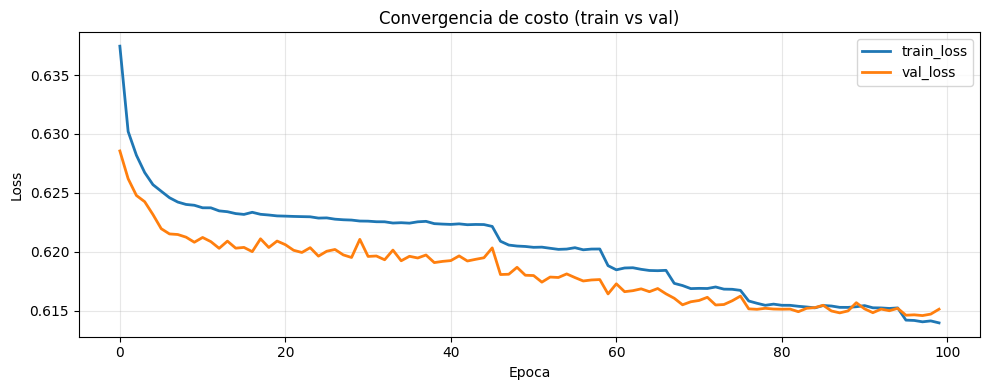

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(history_train, label='train_loss', lw=2)
plt.plot(history_val, label='val_loss', lw=2)
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Convergencia de costo (train vs val)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Chequeo rapido de sobreajuste (diagnostico)
Con los historiales de train y validacion se calcula brecha de perdida y tendencia reciente para identificar si hay sobreajuste, subajuste o comportamiento estable.

In [22]:
# Diagnostico simple de sobreajuste/subajuste
if len(history_train) == 0 or len(history_val) == 0:
    print('Sin historial para diagnostico.')
else:
    final_train = float(history_train[-1])
    final_val = float(history_val[-1])
    gap_final = final_val - final_train

    w = min(5, len(history_train))
    train_trend = float(history_train[-w] - history_train[-1]) if w >= 2 else 0.0
    val_trend = float(history_val[-1] - history_val[-w]) if w >= 2 else 0.0

    print(f'Loss final train: {final_train:.4f}')
    print(f'Loss final val:   {final_val:.4f}')
    print(f'Gap final (val-train): {gap_final:.4f}')

    if gap_final > 0.03 and train_trend > 0 and val_trend > 0:
        print('Diagnostico: posible sobreajuste.')
        print('Sugerencia: subir dropout o weight_decay y reducir epochs.')
    elif gap_final < 0.01 and final_val > 0.60:
        print('Diagnostico: subajuste leve/moderado.')
        print('Sugerencia: mantener LR mas alto por mas epocas y no reducir tan rapido.')
    else:
        print('Diagnostico: comportamiento estable (sin sobreajuste fuerte).')

Loss final train: 0.6140
Loss final val:   0.6151
Gap final (val-train): 0.0012
Diagnostico: subajuste leve/moderado.
Sugerencia: mantener LR mas alto por mas epocas y no reducir tan rapido.


### Curva de precision del modelo (%) por aciertos - Cuadernillo 2

Aqui usamos la formula directa de aciertos en validacion por epoca:
$$\text{Precision}(t)=\frac{\sum_{i=1}^{m}\mathbb{1}[\hat{y}^{(i)}=y^{(i)}]}{m}\times 100$$

Es la forma mas interpretable para clasificacion binaria cuando quieres ver porcentaje de predicciones correctas.

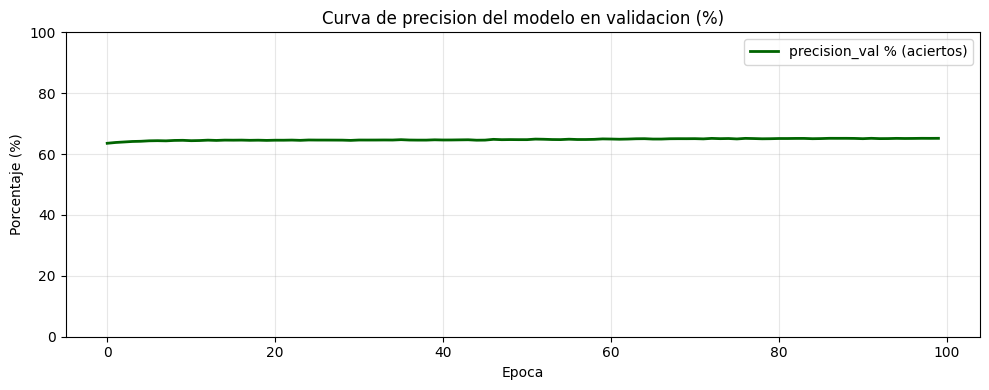

Precision final en validacion: 65.18%


In [23]:
# Curva de precision (%) usando aciertos en validacion
# Precision(t) = (sum(I[y_pred == y_real]) / m) * 100
precision_val = np.array(history_acc_val, dtype=float) * 100.0

plt.figure(figsize=(10, 4))
plt.plot(precision_val, label='precision_val % (aciertos)', lw=2, color='darkgreen')
plt.xlabel('Epoca')
plt.ylabel('Porcentaje (%)')
plt.title('Curva de precision del modelo en validacion (%)')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

if len(precision_val) > 0:
    print(f'Precision final en validacion: {precision_val[-1]:.2f}%')

### Evaluacion detallada en VALIDACION (diagnostico para ajuste) - Cuadernillo 2 + 4

Se usa el mejor checkpoint y el threshold calibrado para revisar estabilidad antes del test final.

Metricas reportadas: loss, accuracy, precision, recall, F1 y matriz de confusion.

In [24]:
# Evaluacion detallada en validacion con mejor checkpoint
best_ckpt = torch.load('/kaggle/working/malware_best.pt', map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

if 'best_threshold' not in globals():
    best_threshold = 0.5

val_metrics, yv_true, yv_pred, yv_prob, cm_val = evaluate_loader(
    model, val_loader, threshold=best_threshold
)

print('=' * 60)
print('METRICAS VALIDACION (mejor checkpoint)')
print('=' * 60)
print(f"Threshold aplicado: {best_threshold:.3f}")
for k, v in val_metrics.items():
    print(f'{k}: {v:.4f}')

print('\nMatriz de confusion (validacion):')
print(cm_val)

METRICAS VALIDACION (mejor checkpoint)
Threshold aplicado: 0.340
loss: 0.6146
acc: 0.6072
precision: 0.5685
recall: 0.8898
f1: 0.6937

Matriz de confusion (validacion):
[[32480 67527]
 [11024 88969]]


### Evaluacion final en TEST (generalizacion) - Cuadernillo 2 + 4

Este bloque reporta el rendimiento final sobre datos no vistos usando el mejor checkpoint y el threshold calibrado en validacion.

In [25]:
best_ckpt = torch.load('/kaggle/working/malware_best.pt', map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

if 'best_threshold' not in globals():
    best_threshold = 0.5

metrics, y_true, y_pred, y_prob, cm_test = evaluate_loader(
    model, test_loader, threshold=best_threshold
)

print('=' * 60)
print('METRICAS TEST (mejor checkpoint)')
print('=' * 60)
print(f"Threshold aplicado: {best_threshold:.3f}")
for k, v in metrics.items():
    print(f'{k}: {v:.4f}')

print('\nMatriz de confusion (test):')
print(cm_test)

METRICAS TEST (mejor checkpoint)
Threshold aplicado: 0.340
loss: 0.6158
acc: 0.6073
precision: 0.5686
recall: 0.8892
f1: 0.6937

Matriz de confusion (test):
[[ 65117 134898]
 [ 22166 177819]]


### Inferencia con el mejor checkpoint
Se carga el modelo óptimo y se predice la probabilidad de malware para ejemplos individuales y para interfaz interactiva.

In [26]:
sample_idx = 0
x_sample = torch.from_numpy(X_test_norm[sample_idx]).float().unsqueeze(0).to(device)
y_real = int(y_test[sample_idx])

if 'best_threshold' not in globals():
    best_threshold = 0.5

with torch.no_grad():
    prob = torch.sigmoid(model(x_sample)).item()

print(f'Probabilidad de malware: {prob:.4f}')
print(f'Threshold aplicado: {best_threshold:.3f}')
print('Predicción:', 'MALWARE' if prob >= best_threshold else 'LIMPIA')
print('Real:', 'MALWARE' if y_real == 1 else 'LIMPIA')

Probabilidad de malware: 0.5916
Threshold aplicado: 0.340
Predicción: MALWARE
Real: LIMPIA


In [27]:
# Guardado de artefactos finales para despliegue
torch.save(model.state_dict(), '/kaggle/working/malware_model_state_dict.pt')
np.save('/kaggle/working/mu_model.npy', mu.astype(np.float32))
np.save('/kaggle/working/sigma_model.npy', sigma.astype(np.float32))

with open('/kaggle/working/columnas_modelo.json', 'w') as f:
    json.dump(df.columns.tolist(), f)

print('Artefactos guardados:')
print('- malware_model_state_dict.pt')
print('- mu_model.npy')
print('- sigma_model.npy')
print('- columnas_modelo.json')

Artefactos guardados:
- malware_model_state_dict.pt
- mu_model.npy
- sigma_model.npy
- columnas_modelo.json


In [28]:
# Runbook corto de ejecución
print('1) Ejecutar carga + preprocesamiento')
print('2) Ejecutar split + normalización + checkpoint de datos')
print('3) Ejecutar tensores + dataset/dataloader')
print('4) Ejecutar modelo + entrenamiento + checkpoints')
print('5) Ejecutar evaluación final + gradio')

1) Ejecutar carga + preprocesamiento
2) Ejecutar split + normalización + checkpoint de datos
3) Ejecutar tensores + dataset/dataloader
4) Ejecutar modelo + entrenamiento + checkpoints
5) Ejecutar evaluación final + gradio


## Interfaz Gradio (PyTorch)
La interfaz usa el modelo guardado en checkpoint y predice probabilidad de malware con salida binaria e indicador de riesgo.

In [29]:
import gradio as gr

feature_names = df.columns.tolist()
feature_medians = df.median(numeric_only=True)

# Para UI, usamos las 10 features mas influyentes de la primera capa
first_layer_weights = model.net[0].weight.detach().cpu().numpy()
importance = np.mean(np.abs(first_layer_weights), axis=0)
top_idx = np.argsort(importance)[::-1][:10]
top_features = [feature_names[i] for i in top_idx]

if 'best_threshold' not in globals():
    best_threshold = 0.5

def predecir_malware_pytorch(*inputs):
    x = feature_medians.reindex(feature_names).fillna(0).values.astype(np.float32)

    for i, idx in enumerate(top_idx):
        x[idx] = float(inputs[i])

    x_norm = (x - mu) / sigma
    x_tensor = torch.from_numpy(x_norm).float().unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(x_tensor)).item()

    pred = 'Malware detectado' if prob >= best_threshold else 'Maquina limpia'
    riesgo = 'Alto' if prob >= 0.75 else ('Medio' if prob >= best_threshold else 'Bajo')
    return pred, f'{prob*100:.2f}%', riesgo, f'{best_threshold:.3f}'

inputs = []
for feat in top_features:
    vals = df[feat].dropna()
    inputs.append(
        gr.Slider(
            minimum=float(vals.min()),
            maximum=float(vals.max()),
            value=float(vals.median()),
            label=feat,
        )
    )

demo = gr.Interface(
    fn=predecir_malware_pytorch,
    inputs=inputs,
    outputs=[
        gr.Textbox(label='Resultado'),
        gr.Textbox(label='Probabilidad de malware'),
        gr.Textbox(label='Nivel de riesgo'),
        gr.Textbox(label='Threshold aplicado'),
    ],
    title='Microsoft Malware Prediction - PyTorch',
    description='Inferencia con checkpoint del modelo de clasificacion binaria y threshold calibrado en validacion.',
    flagging_mode='never',
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f284af2eb65af66ac0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [30]:
print('=' * 70)
print('RESUMEN FINAL - LAB 5.2 PYTORCH')
print('=' * 70)
print(f"Muestras train: {len(y_train):,}")
print(f"Muestras test:  {len(y_test):,}")
print(f"Features:       {X_train.shape[1]}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print('Checkpoints:')
print(' - /kaggle/working/malware_best.pt')
print(' - /kaggle/working/malware_last.pt')
print('Artefactos despliegue:')
print(' - /kaggle/working/malware_model_state_dict.pt')
print(' - /kaggle/working/mu_model.npy')
print(' - /kaggle/working/sigma_model.npy')
print(' - /kaggle/working/columnas_modelo.json')

RESUMEN FINAL - LAB 5.2 PYTORCH
Muestras train: 1,400,000
Muestras test:  400,000
Features:       170
Mejor val_loss: 0.6146
Checkpoints:
 - /kaggle/working/malware_best.pt
 - /kaggle/working/malware_last.pt
Artefactos despliegue:
 - /kaggle/working/malware_model_state_dict.pt
 - /kaggle/working/mu_model.npy
 - /kaggle/working/sigma_model.npy
 - /kaggle/working/columnas_modelo.json
